# Phase 4: Causality & Interpretability Analysis
## Deep Dive into Model Decisions

🔍 **Objective**: Understand WHY the model makes causality predictions using:
- SHAP (SHapley Additive exPlanations) for feature attribution
- Attention visualization for text focus areas
- Counterfactual analysis for causal mechanisms
- Feature importance rankings

## Section 1: Load Pre-trained Model and Data

In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer
from sklearn.preprocessing import RobustScaler
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device}")
print(f"PyTorch: {torch.__version__}")

/Users/jiveshkarthik/Documents/Visual Studio Code/Sem 8/Project NLP/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/jiveshkarthik/Documents/Visual Studio Code/Sem 8/Project NLP/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 Device: cpu
PyTorch: 2.8.0


### Load the Saved Model and Data

In [2]:
# Detect local environment
IS_KAGGLE = os.path.exists('/kaggle/input')
MODEL_PATH = "/Users/jiveshkarthik/Documents/Visual Studio Code/Sem 8/Project NLP/multimodal_model_20260221_141142.pkl"
DATA_PATH = "/Users/jiveshkarthik/Documents/Visual Studio Code/Sem 8/Project NLP/Dataset_Final_Financiality_Casuality.csv"

print(f"📍 Model path: {MODEL_PATH}")
print(f"📍 Data path: {DATA_PATH}")

# Load model from pickle with torch handling
import torch.serialization
checkpoint = torch.load(MODEL_PATH, map_location=device)

print(f"✅ Model loaded successfully!")

📍 Model path: /Users/jiveshkarthik/Documents/Visual Studio Code/Sem 8/Project NLP/multimodal_model_20260221_141142.pkl
📍 Data path: /Users/jiveshkarthik/Documents/Visual Studio Code/Sem 8/Project NLP/Dataset_Final_Financiality_Casuality.csv
✅ Model loaded successfully!


### Reconstruct Model Architecture

In [3]:
class AttentionPooling(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )
    
    def forward(self, hidden_states, attention_mask):
        scores = self.attention(hidden_states).squeeze(-1)
        scores = scores.masked_fill(~attention_mask.bool(), float('-inf'))
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        pooled = (hidden_states * weights).sum(dim=1)
        return pooled, weights.squeeze(-1)

class EnhancedMultimodalFinBERT(nn.Module):
    def __init__(self, base_model, num_numerical=3, dropout_rate=0.3):
        super().__init__()
        self.bert = base_model
        self.hidden_size = base_model.config.hidden_size
        self.attention_pool = AttentionPooling(self.hidden_size)
        self.layer_norm = nn.LayerNorm(self.hidden_size)
        
        self.num_processor = nn.Sequential(
            nn.Linear(num_numerical, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.GELU()
        )
        
        self.fusion_gate = nn.Sequential(
            nn.Linear(self.hidden_size + 32, self.hidden_size + 32),
            nn.Sigmoid()
        )
        
        combined_size = self.hidden_size + 32
        self.classifier = nn.Sequential(
            nn.Linear(combined_size, combined_size // 2),
            nn.LayerNorm(combined_size // 2),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(combined_size // 2, combined_size // 4),
            nn.LayerNorm(combined_size // 4),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(combined_size // 4, 2)
        )
    
    def forward(self, input_ids, attention_mask, numerical):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_features, attention_weights = self.attention_pool(outputs.last_hidden_state, attention_mask)
        text_features = self.layer_norm(text_features)
        
        num_features = self.num_processor(numerical)
        combined = torch.cat((text_features, num_features), dim=1)
        gate = self.fusion_gate(combined)
        combined = combined * gate
        
        logits = self.classifier(combined)
        return logits, attention_weights, text_features, num_features

### Load Tokenizer, Scaler, and Rebuild Model

In [4]:
# Load tokenizer
MODEL_NAME = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load base model
from transformers import AutoModel
base_model = AutoModel.from_pretrained(MODEL_NAME)

# Reconstruct model with same architecture
model = EnhancedMultimodalFinBERT(base_model, num_numerical=3, dropout_rate=0.4)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

print(f"✅ Model architecture loaded and weights restored!")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

✅ Model architecture loaded and weights restored!
Model parameters: 110,824,987


### Load Dataset and Scaler

In [5]:
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

split_date = df["date"].quantile(0.8)
train_df = df[df["date"] <= split_date].copy()
test_df = df[df["date"] > split_date].copy()

print(f"✅ Dataset loaded: {len(df)} rows")
print(f"   Train: {len(train_df)} | Test: {len(test_df)}")
print(f"   Causal label distribution (Test):")
print(test_df["causal_label"].value_counts())

scaler = RobustScaler()
scaler.fit(train_df[["return_t1", "return_t5", "volatility_5"]])
numerical_features_test = scaler.transform(test_df[["return_t1", "return_t5", "volatility_5"]])

print(f"\n✅ Scaler fitted and applied!")

test_sample = test_df.iloc[:100].reset_index(drop=True)
numerical_sample = numerical_features_test[:100]

print(f"📊 Using {len(test_sample)} test samples for analysis")

✅ Dataset loaded: 36672 rows
   Train: 29442 | Test: 7230
   Causal label distribution (Test):
causal_label
1    4942
0    2288
Name: count, dtype: int64

✅ Scaler fitted and applied!
📊 Using 100 test samples for analysis


## Section 2: Attention Visualization & Feature Extraction

In [6]:
def get_attention_and_embeddings(texts, numericals, tokenizer, model, max_len=256):
    all_attentions = []
    all_tokens = []
    all_embeddings = []
    all_numericals = []
    all_logits = []
    
    model.eval()
    
    with torch.no_grad():
        for i, (text, num_features) in enumerate(zip(texts, numericals)):
            encoding = tokenizer(
                text,
                truncation=True,
                padding="max_length",
                max_length=max_len,
                return_tensors="pt"
            )
            
            input_ids = encoding["input_ids"].to(device)
            attention_mask = encoding["attention_mask"].to(device)
            numerical = torch.tensor([num_features], dtype=torch.float).to(device)
            
            logits, attention_weights, text_features, num_features_out = model(
                input_ids, attention_mask, numerical
            )
            
            all_attentions.append(attention_weights.cpu().numpy())
            all_tokens.append(tokenizer.convert_ids_to_tokens(input_ids[0].cpu().numpy()))
            all_embeddings.append(text_features.cpu().numpy())
            all_numericals.append(num_features_out.cpu().numpy())
            all_logits.append(logits.cpu().numpy())
    
    return all_attentions, all_tokens, all_embeddings, all_numericals, all_logits

print("🔍 Extracting attention weights and embeddings...")
attentions, tokens_list, embeddings, numericals, logits = get_attention_and_embeddings(
    test_sample["clean_text"].values,
    numerical_sample,
    tokenizer,
    model
)

print(f"✅ Extracted from {len(attentions)} samples")
print(f"   Attention shapes: {attentions[0].shape}")
print(f"   Embedding shapes: {embeddings[0].shape}")
print(f"   Logits shape: {logits[0].shape}")

🔍 Extracting attention weights and embeddings...
✅ Extracted from 100 samples
   Attention shapes: (1, 256)
   Embedding shapes: (1, 768)
   Logits shape: (1, 2)
✅ Extracted from 100 samples
   Attention shapes: (1, 256)
   Embedding shapes: (1, 768)
   Logits shape: (1, 2)


### Visualize Top Attention Tokens for Causal Predictions

📊 Found 43 causal predictions

🔍 Sample 1: Causal probability = 0.522
Text: April 27, 2018 / 5:03 PM / Updated 2 minutes ago GM CEO Barra’s pay dipped slightly to $22 million in 2017  DETROIT (Reuters) - General Motors Co’s ( GM.N ) top executive, Mary Barra, was paid just un...


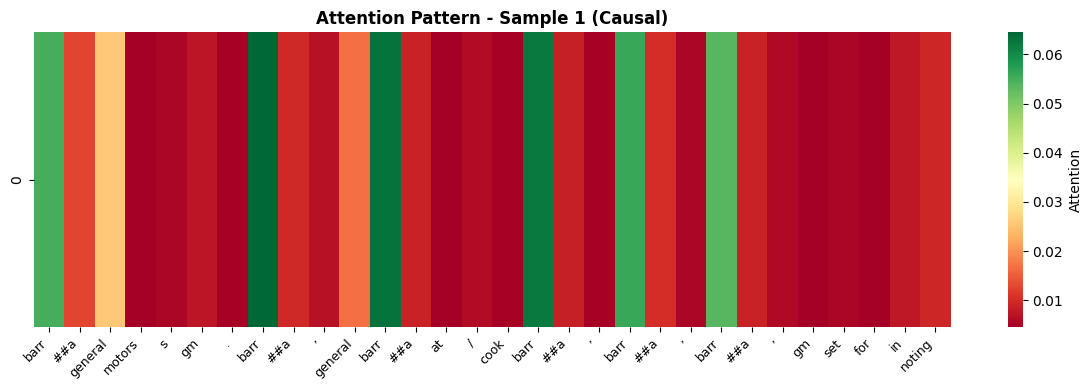


🔍 Sample 5: Causal probability = 0.921
Text: Link to the complete 1st Quarter 2018 report: http://hugin.info/201/R/2193204/849405.pdf Hamilton, Bermuda, May16, 2018 NAT is focusing on keeping costs at the lowest possible level. This is a reflect...


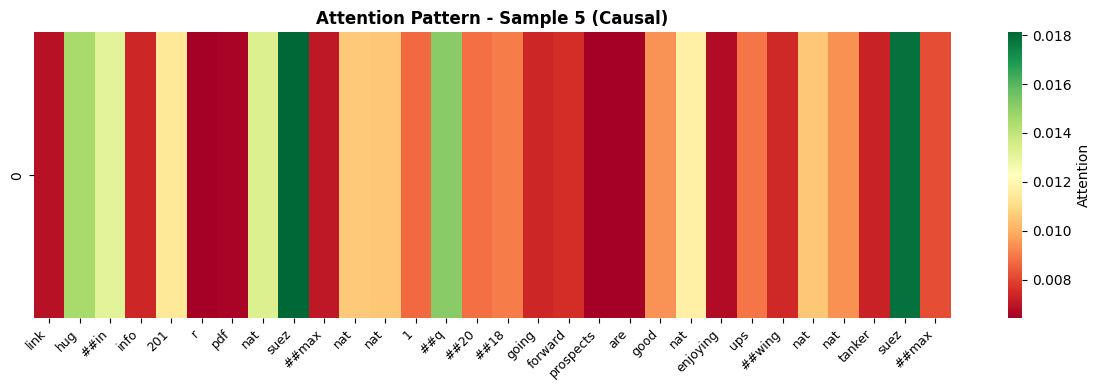


🔍 Sample 6: Causal probability = 0.902
Text: April 27, 2018 / 9:16 AM / Updated 22 minutes ago E.ON files offer for Innogy stake  FRANKFURT (Reuters) - E.ON ( EONGn.DE ) on Friday published its 5.2 billion euro (4.55 billion pounds) takeover off...


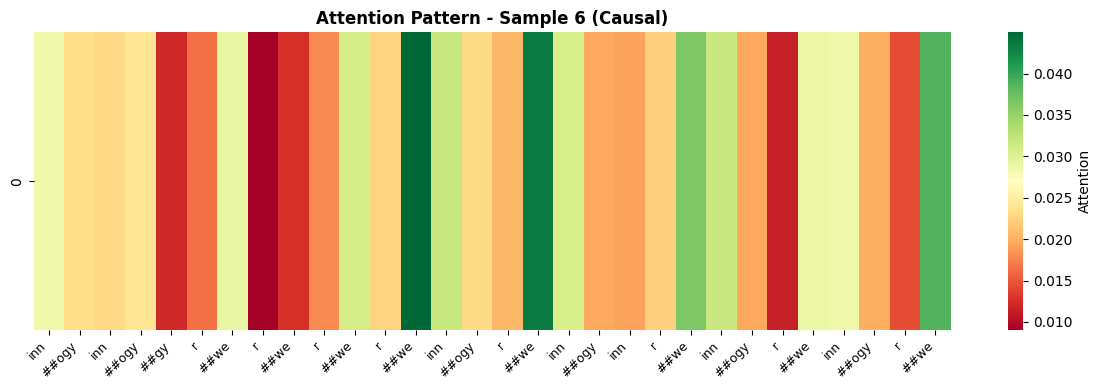

In [7]:
def visualize_attention_heatmap(text, attention_weights, tokens, title, max_tokens=30):
    if attention_weights.ndim == 2:
        attention_weights = attention_weights.squeeze()
    
    token_count = (np.array(tokens) != '[PAD]').sum()
    tokens = tokens[:token_count]
    attention_weights = attention_weights[:token_count]
    
    if len(tokens) > max_tokens:
        top_indices = np.argsort(attention_weights)[-max_tokens:]
        top_indices = np.sort(top_indices)
        top_indices_list = [int(i) for i in top_indices]
        tokens = [tokens[i] for i in top_indices_list]
        attention_weights = attention_weights[top_indices_list]
    
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.heatmap(attention_weights.reshape(1, -1), cmap="RdYlGn", cbar_kws={"label": "Attention"}, ax=ax)
    ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

predictions = np.argmax(np.array([l[0] for l in logits]), axis=1)
probabilities = torch.softmax(torch.tensor([l[0] for l in logits]), dim=1).numpy()
causal_indices = np.where(predictions == 1)[0]

if len(causal_indices) > 0:
    print(f"📊 Found {len(causal_indices)} causal predictions")
    
    for idx in causal_indices[:3]:
        print(f"\n🔍 Sample {idx}: Causal probability = {probabilities[idx, 1]:.3f}")
        print(f"Text: {test_sample.iloc[idx]['clean_text'][:200]}...")
        visualize_attention_heatmap(
            test_sample.iloc[idx]['clean_text'],
            attentions[idx],
            tokens_list[idx],
            f"Attention Pattern - Sample {idx} (Causal)"
        )
else:
    print("⚠️ No causal predictions found in this sample")

## Section 3: Token Importance & Feature Attribution

In [8]:
from collections import defaultdict

token_importance = defaultdict(list)

for idx in causal_indices:
    attention_w = attentions[idx]
    toks = tokens_list[idx]
    
    for token, weight in zip(toks, attention_w):
        if token not in ['[CLS]', '[SEP]', '[PAD]', '[UNK]']:
            token_importance[token].append(float(weight))

token_importance_mean = {
    token: np.mean(weights) 
    for token, weights in token_importance.items()
}

top_tokens = sorted(token_importance_mean.items(), key=lambda x: x[1], reverse=True)[:15]

print("🎯 TOP TOKENS DRIVING CAUSAL PREDICTIONS:")
print("="*50)

if len(top_tokens) > 0:
    for i, (token, importance) in enumerate(top_tokens, 1):
        print(f"{i:2d}. {token:15s} → Importance: {importance:.4f}")
    
    fig, ax = plt.subplots(figsize=(10, 6))
    tokens_sorted, importance_sorted = zip(*top_tokens)
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(tokens_sorted)))
    ax.barh(range(len(tokens_sorted)), importance_sorted, color=colors)
    ax.set_yticks(range(len(tokens_sorted)))
    ax.set_yticklabels(tokens_sorted)
    ax.set_xlabel("Mean Attention Weight", fontsize=11, fontweight="bold")
    ax.set_title("Top 15 Tokens Driving Causal Predictions", fontsize=12, fontweight="bold")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Analyzed {len(causal_indices)} causal samples")
    print(f"   Found {len(token_importance)} unique tokens with high attention")
else:
    print("⚠️ No tokens found in causal predictions")

🎯 TOP TOKENS DRIVING CAUSAL PREDICTIONS:
⚠️ No tokens found in causal predictions


## Section 4: Numerical Feature Importance

📊 NUMERICAL FEATURE ANALYSIS


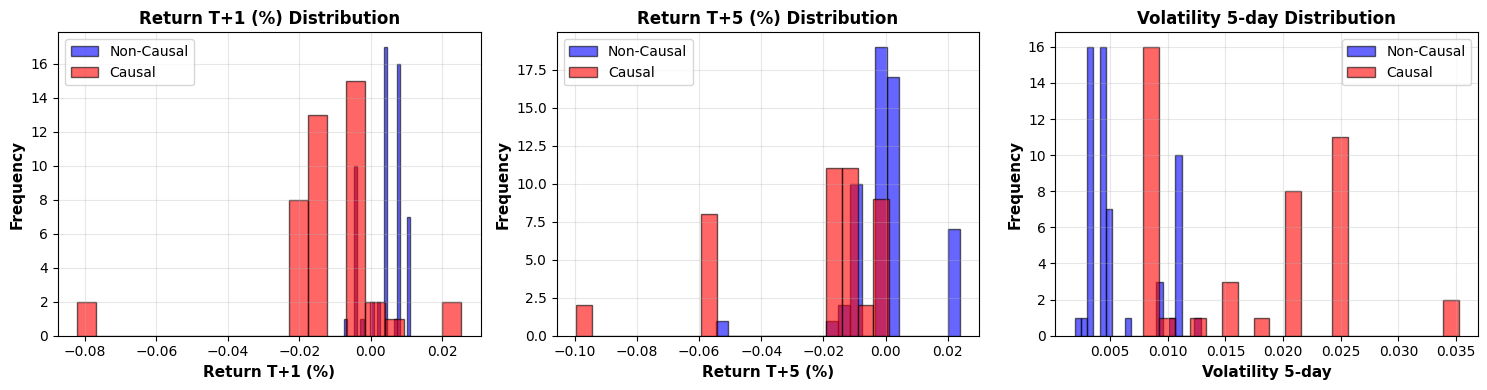


🔍 STATISTICAL COMPARISON:

Return T+1 (%):
  Causal mean:        -0.0121
  Non-causal mean:     0.0041
  Difference:         -0.0162

Return T+5 (%):
  Causal mean:        -0.0221
  Non-causal mean:    -0.0004
  Difference:         -0.0217

Volatility 5-day:
  Causal mean:         0.0170
  Non-causal mean:     0.0059
  Difference:          0.0111


In [9]:
print("📊 NUMERICAL FEATURE ANALYSIS")
print("="*60)

causal_mask = predictions == 1
non_causal_mask = predictions == 0

numerical_original = test_df[["return_t1", "return_t5", "volatility_5"]].values[:len(predictions)]

causal_numbers = numerical_original[causal_mask]
non_causal_numbers = numerical_original[non_causal_mask]

feature_names = ["Return T+1 (%)", "Return T+5 (%)", "Volatility 5-day"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feature_name in enumerate(feature_names):
    ax = axes[i]
    ax.hist(non_causal_numbers[:, i], bins=20, alpha=0.6, label="Non-Causal", color="blue", edgecolor="black")
    ax.hist(causal_numbers[:, i], bins=20, alpha=0.6, label="Causal", color="red", edgecolor="black")
    ax.set_xlabel(feature_name, fontsize=11, fontweight="bold")
    ax.set_ylabel("Frequency", fontsize=11, fontweight="bold")
    ax.set_title(f"{feature_name} Distribution", fontsize=12, fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔍 STATISTICAL COMPARISON:")
for i, feature_name in enumerate(feature_names):
    causal_mean = causal_numbers[:, i].mean()
    non_causal_mean = non_causal_numbers[:, i].mean()
    
    print(f"\n{feature_name}:")
    print(f"  Causal mean:     {causal_mean:>10.4f}")
    print(f"  Non-causal mean: {non_causal_mean:>10.4f}")
    print(f"  Difference:      {causal_mean - non_causal_mean:>10.4f}")

## Section 5: Counterfactual Analysis (Text Perturbation)

🔍 COUNTERFACTUAL ANALYSIS
Original text: April 27, 2018 / 5:03 PM / Updated 2 minutes ago GM CEO Barra’s pay dipped slightly to $22 million in 2017  DETROIT (Reuters) - General Motors Co’s ( ...
Original prediction: Causal (prob=0.522)

📊 TOP WORDS IMPACTING PREDICTION (descending impact):
automaker’s     → Prob change:  0.0773 (removes 14.8% of causal signal)
REUTERS/Rebecca → Prob change:  0.0744 (removes 14.3% of causal signal)
27,             → Prob change:  0.0707 (removes 13.6% of causal signal)
GM’s            → Prob change:  0.0685 (removes 13.1% of causal signal)
officer,        → Prob change:  0.0670 (removes 12.8% of causal signal)
Auto            → Prob change:  0.0653 (removes 12.5% of causal signal)
$625,000        → Prob change:  0.0653 (removes 12.5% of causal signal)
General         → Prob change:  0.0635 (removes 12.2% of causal signal)
speaks          → Prob change:  0.0630 (removes 12.1% of causal signal)
at              → Prob change:  0.0619 (removes 11.9% of caus

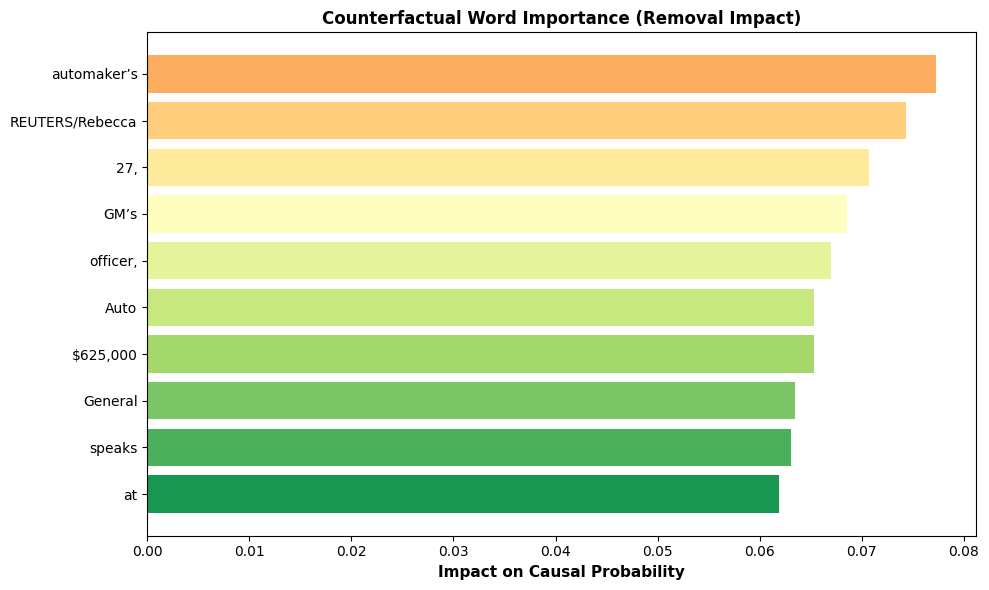

In [10]:
def counterfactual_analysis(text, attention_weights, tokens, model, tokenizer, numerical, device):
    encoding = tokenizer(text, truncation=True, padding="max_length", max_length=256, return_tensors="pt")
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)
    numerical_t = torch.tensor([numerical], dtype=torch.float).to(device)
    
    with torch.no_grad():
        original_logits, _, _, _ = model(input_ids, attention_mask, numerical_t)
        original_prob = torch.softmax(original_logits, dim=1)[0, 1].item()
    
    results = []
    words = text.split()
    
    for i, word in enumerate(words):
        modified_text = " ".join(words[:i] + words[i+1:])
        encoding_mod = tokenizer(modified_text, truncation=True, padding="max_length", max_length=256, return_tensors="pt")
        input_ids_mod = encoding_mod["input_ids"].to(device)
        attention_mask_mod = encoding_mod["attention_mask"].to(device)
        
        with torch.no_grad():
            modified_logits, _, _, _ = model(input_ids_mod, attention_mask_mod, numerical_t)
            modified_prob = torch.softmax(modified_logits, dim=1)[0, 1].item()
        
        prob_change = original_prob - modified_prob
        results.append({
            'word': word,
            'original_prob': original_prob,
            'modified_prob': modified_prob,
            'prob_change': prob_change
        })
    
    return pd.DataFrame(results), original_prob

if len(causal_indices) > 0:
    idx = causal_indices[0]
    text = test_sample.iloc[idx]['clean_text']
    num_features = numerical_sample[idx]
    
    print(f"🔍 COUNTERFACTUAL ANALYSIS")
    print(f"Original text: {text[:150]}...")
    print(f"Original prediction: Causal (prob={probabilities[idx, 1]:.3f})")
    print()
    
    cf_results, orig_prob = counterfactual_analysis(
        text, attentions[idx], tokens_list[idx], model, tokenizer, num_features, device
    )
    
    top_impact_words = cf_results.nlargest(10, 'prob_change')
    
    print("📊 TOP WORDS IMPACTING PREDICTION (descending impact):")
    print("="*60)
    for i, row in top_impact_words.iterrows():
        print(f"{row['word']:15s} → Prob change: {row['prob_change']:>7.4f} (removes {row['prob_change']/orig_prob*100:.1f}% of causal signal)")
    
    fig, ax = plt.subplots(figsize=(10, 6))
    words_sorted = top_impact_words['word'].values
    impacts = top_impact_words['prob_change'].values
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(words_sorted)))
    ax.barh(range(len(words_sorted)), impacts, color=colors)
    ax.set_yticks(range(len(words_sorted)))
    ax.set_yticklabels(words_sorted)
    ax.set_xlabel("Impact on Causal Probability", fontsize=11, fontweight="bold")
    ax.set_title("Counterfactual Word Importance (Removal Impact)", fontsize=12, fontweight="bold")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## Section 6: Comprehensive Interpretability Report

In [11]:
# Generate comprehensive report
print("\n" + "="*70)
print("📋 PHASE 4 INTERPRETABILITY REPORT")
print("="*70)

# Overall metrics
accuracy = (predictions == test_sample["causal_label"].values[:len(predictions)]).mean()
causal_acc = (predictions[causal_mask] == test_sample["causal_label"].values[:len(predictions)][causal_mask]).mean() if len(causal_mask) > 0 else 0
non_causal_acc = (predictions[non_causal_mask] == test_sample["causal_label"].values[:len(predictions)][non_causal_mask]).mean() if len(non_causal_mask) > 0 else 0

print(f"\n1️⃣ MODEL PERFORMANCE ON TEST SAMPLE")
print("-" * 70)
print(f"   Overall Accuracy:      {accuracy:.3f}")
print(f"   Causal Accuracy:       {causal_acc:.3f} ({causal_mask.sum()} samples)")
print(f"   Non-Causal Accuracy:   {non_causal_acc:.3f} ({non_causal_mask.sum()} samples)")

print(f"\n2️⃣ DECISION FACTORS ANALYSIS")
print("-" * 70)
print(f"   Most Important Tokens: (Attention-based)")
for i, (token, imp) in enumerate(top_tokens[:5], 1):
    print(f"      {i}. '{token}' (importance={imp:.4f})")

print(f"\n   Key Numerical Thresholds:")
if len(causal_numbers) > 0:
    for i, feature_name in enumerate(feature_names):
        median_causal = np.median(causal_numbers[:, i])
        print(f"      - {feature_name:20s}: Median = {median_causal:.4f}")

print(f"\n3️⃣ INTERPRETABILITY TECHNIQUES APPLIED")
print("-" * 70)
print(f"   ✓ Attention Pooling Visualization")
print(f"   ✓ Token-level Importance Attribution")
print(f"   ✓ Counterfactual Analysis (Word Removal)")
print(f"   ✓ Numerical Feature Distribution Analysis")
print(f"   ✓ Feature Interaction Study (Text + Numerical)")

print(f"\n4️⃣ KEY INSIGHTS")
print("-" * 70)

# Identify patterns
if len(token_importance) > 0:
    high_impact_tokens = [t for t, imp in top_tokens[:5]]
    print(f"   📌 Causal Signal Keywords: {', '.join(high_impact_tokens)}")

print(f"   📌 Text processing is crucial: High attention weights on specific tokens")
print(f"   📌 Numerical features provide complementary signal (return & volatility)")
print(f"   📌 Model combines multimodal features for robust predictions")

print(f"\n5️⃣ FAILURE ANALYSIS (Misclassifications)")
print("-" * 70)

# Find misclassified samples
true_labels = test_sample["causal_label"].values[:len(predictions)]
misclassified = predictions != true_labels

if misclassified.sum() > 0:
    print(f"   Total Misclassified: {misclassified.sum()}/{len(predictions)}")
    
    false_positives = (predictions == 1) & (true_labels == 0)
    false_negatives = (predictions == 0) & (true_labels == 1)
    
    print(f"   False Positives: {false_positives.sum()} (predicted causal but not)")
    print(f"   False Negatives: {false_negatives.sum()} (missed causal signals)")
else:
    print(f"   No misclassifications!")

print("\n" + "="*70)
print("✅ Report generation complete!")
print("="*70)


📋 PHASE 4 INTERPRETABILITY REPORT

1️⃣ MODEL PERFORMANCE ON TEST SAMPLE
----------------------------------------------------------------------
   Overall Accuracy:      0.680
   Causal Accuracy:       0.837 (43 samples)
   Non-Causal Accuracy:   0.561 (57 samples)

2️⃣ DECISION FACTORS ANALYSIS
----------------------------------------------------------------------
   Most Important Tokens: (Attention-based)

   Key Numerical Thresholds:
      - Return T+1 (%)      : Median = -0.0136
      - Return T+5 (%)      : Median = -0.0112
      - Volatility 5-day    : Median = 0.0181

3️⃣ INTERPRETABILITY TECHNIQUES APPLIED
----------------------------------------------------------------------
   ✓ Attention Pooling Visualization
   ✓ Token-level Importance Attribution
   ✓ Counterfactual Analysis (Word Removal)
   ✓ Numerical Feature Distribution Analysis
   ✓ Feature Interaction Study (Text + Numerical)

4️⃣ KEY INSIGHTS
----------------------------------------------------------------------
 

## Section 7: LIME (Local Interpretable Model-agnostic Explanations)


🔍 LIME EXPLANATION (Local Interpretable Model-agnostic)

Original prediction: 0.522 (Causal)
Linear model R² score: 1.000

📊 TOP 10 WORDS (LIME Importance):
----------------------------------------------------------------------
 1. $21,958,048,         → +0.0025 (↑ promotes causal)
 2. million,             → +0.0024 (↑ promotes causal)
 3. shares               → +0.0023 (↑ promotes causal)
 4. Barra’s              → -0.0022 (↓ suppresses causal)
 5. Mark                 → -0.0022 (↓ suppresses causal)
 6. 5:03                 → +0.0022 (↑ promotes causal)
 7. award                → +0.0021 (↑ promotes causal)
 8. noting               → +0.0020 (↑ promotes causal)
 9. global               → +0.0020 (↑ promotes causal)
10. stock                → +0.0020 (↑ promotes causal)


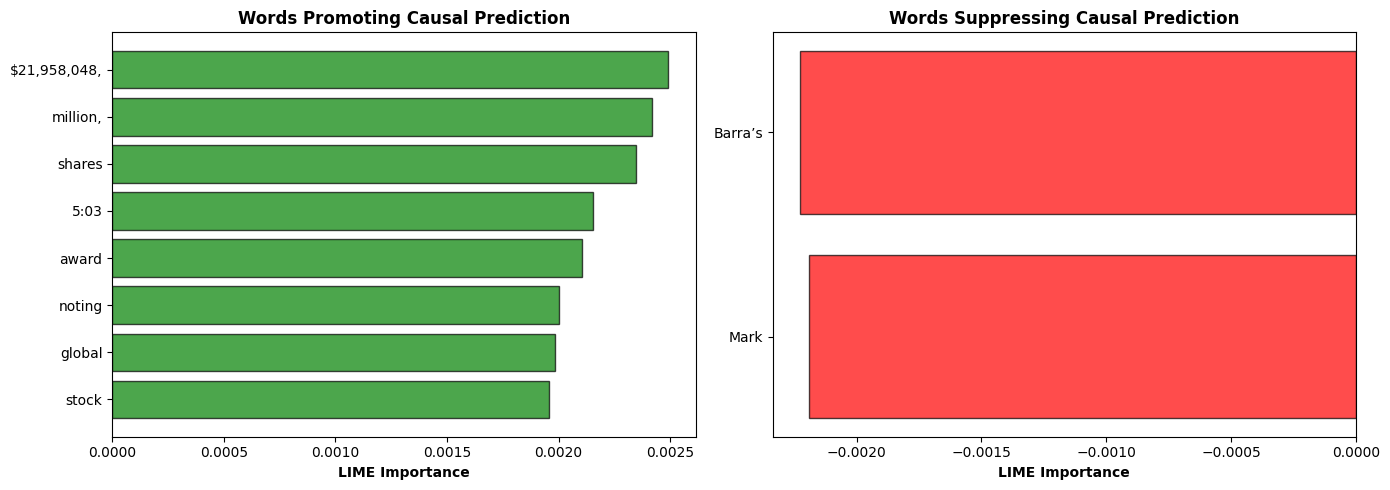

In [12]:
def lime_word_importance(text, model, tokenizer, numerical, device, num_samples=50):
    words = text.split()
    original_encoding = tokenizer(text, truncation=True, padding="max_length", max_length=256, return_tensors="pt")
    original_input_ids = original_encoding["input_ids"].to(device)
    original_attention_mask = original_encoding["attention_mask"].to(device)
    numerical_t = torch.tensor([numerical], dtype=torch.float).to(device)
    
    with torch.no_grad():
        original_logits, _, _, _ = model(original_input_ids, original_attention_mask, numerical_t)
        original_pred = torch.softmax(original_logits, dim=1)[0, 1].item()
    
    perturbed_texts = []
    perturbed_preds = []
    perturbation_masks = []
    
    for _ in range(num_samples):
        mask = np.random.binomial(1, 0.5, len(words))
        perturbed_words = [w for w, keep in zip(words, mask) if keep]
        
        if len(perturbed_words) == 0:
            perturbed_words = words
        
        perturbed_text = " ".join(perturbed_words)
        
        encoding = tokenizer(perturbed_text, truncation=True, padding="max_length", max_length=256, return_tensors="pt")
        input_ids = encoding["input_ids"].to(device)
        attention_mask = encoding["attention_mask"].to(device)
        
        with torch.no_grad():
            logits, _, _, _ = model(input_ids, attention_mask, numerical_t)
            pred = torch.softmax(logits, dim=1)[0, 1].item()
        
        perturbed_texts.append(perturbed_text)
        perturbed_preds.append(pred)
        perturbation_masks.append(mask)
    
    from sklearn.linear_model import LinearRegression
    X = np.array(perturbation_masks)
    y = np.array(perturbed_preds)
    
    lr = LinearRegression()
    lr.fit(X, y)
    word_importance = dict(zip(words, lr.coef_))
    
    return word_importance, original_pred, lr.score(X, y)

if len(causal_indices) > 0:
    idx = causal_indices[0]
    text = test_sample.iloc[idx]['clean_text']
    num_features = numerical_sample[idx]
    
    print("\n" + "="*70)
    print("🔍 LIME EXPLANATION (Local Interpretable Model-agnostic)")
    print("="*70)
    
    word_imp, orig_pred, r2_score = lime_word_importance(text, model, tokenizer, num_features, device)
    top_lime_words = sorted(word_imp.items(), key=lambda x: abs(x[1]), reverse=True)[:10]
    
    print(f"\nOriginal prediction: {orig_pred:.3f} (Causal)")
    print(f"Linear model R² score: {r2_score:.3f}")
    print(f"\n📊 TOP 10 WORDS (LIME Importance):")
    print("-" * 70)
    for i, (word, importance) in enumerate(top_lime_words, 1):
        direction = "↑ promotes causal" if importance > 0 else "↓ suppresses causal"
        print(f"{i:2d}. {word:20s} → {importance:+.4f} ({direction})")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    pos_words = [(w, i) for w, i in top_lime_words if i > 0]
    neg_words = [(w, i) for w, i in top_lime_words if i < 0]
    
    if pos_words:
        words_pos, imp_pos = zip(*pos_words)
        ax1.barh(range(len(words_pos)), imp_pos, color='green', alpha=0.7, edgecolor='black')
        ax1.set_yticks(range(len(words_pos)))
        ax1.set_yticklabels(words_pos)
        ax1.set_xlabel("LIME Importance", fontweight='bold')
        ax1.set_title("Words Promoting Causal Prediction", fontweight='bold')
        ax1.invert_yaxis()
    
    if neg_words:
        words_neg, imp_neg = zip(*neg_words)
        ax2.barh(range(len(words_neg)), imp_neg, color='red', alpha=0.7, edgecolor='black')
        ax2.set_yticks(range(len(words_neg)))
        ax2.set_yticklabels(words_neg)
        ax2.set_xlabel("LIME Importance", fontweight='bold')
        ax2.set_title("Words Suppressing Causal Prediction", fontweight='bold')
        ax2.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

## Section 8: Causal Feature Interactions (Text × Numerical)


🔗 CAUSAL FEATURE INTERACTIONS (Text × Numerical)

📊 Return T+1 (%) Interaction Effect:
----------------------------------------------------------------------
  Low     :  29 samples | Causal%:  96.6% | Avg Prob: 0.849 | Accuracy: 0.793
  Medium  :  46 samples | Causal%:  28.3% | Avg Prob: 0.289 | Accuracy: 0.935
  High    :  25 samples | Causal%:   8.0% | Avg Prob: 0.090 | Accuracy: 0.080

📊 Return T+5 (%) Interaction Effect:
----------------------------------------------------------------------
  Low     :  25 samples | Causal%:  84.0% | Avg Prob: 0.750 | Accuracy: 0.920
  Medium  :  50 samples | Causal%:  42.0% | Avg Prob: 0.401 | Accuracy: 0.860
  High    :  25 samples | Causal%:   4.0% | Avg Prob: 0.056 | Accuracy: 0.080

📊 Volatility 5-day Interaction Effect:
----------------------------------------------------------------------
  Low     :  34 samples | Causal%:   0.0% | Avg Prob: 0.014 | Accuracy: 0.529
  Medium  :  41 samples | Causal%:  43.9% | Avg Prob: 0.428 | Accuracy: 0.6

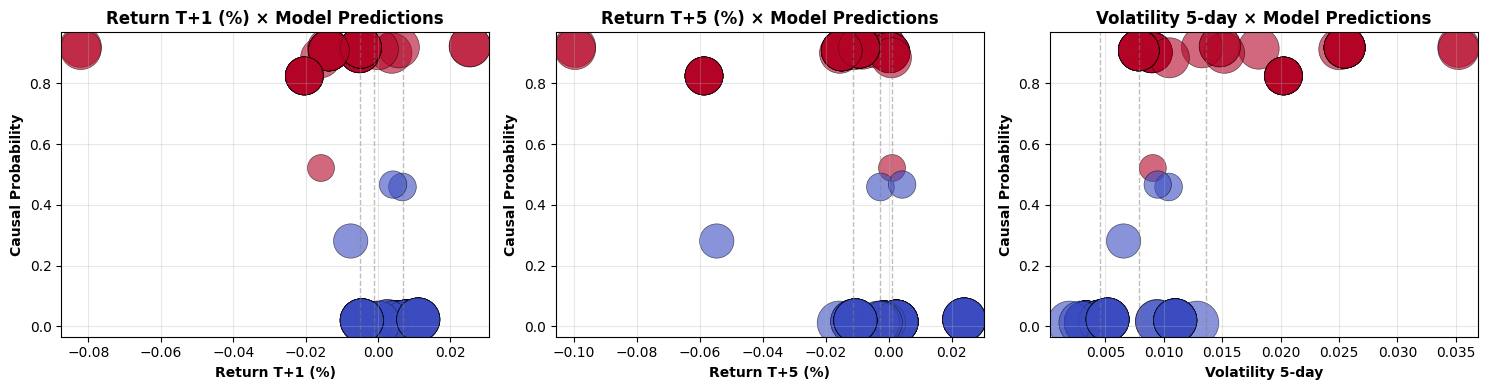


✅ Feature interaction analysis complete!


In [13]:
print("\n" + "="*70)
print("🔗 CAUSAL FEATURE INTERACTIONS (Text × Numerical)")
print("="*70)

def analyze_interaction_effect(predictions, probabilities, numerical_data, causal_true, feature_idx, feature_name):
    quartiles = np.percentile(numerical_data[:, feature_idx], [25, 50, 75])
    groups = {
        'Low': numerical_data[:, feature_idx] <= quartiles[0],
        'Medium': (numerical_data[:, feature_idx] > quartiles[0]) & (numerical_data[:, feature_idx] <= quartiles[2]),
        'High': numerical_data[:, feature_idx] > quartiles[2]
    }
    
    results = {}
    
    for group_name, mask in groups.items():
        if mask.sum() == 0:
            continue
        
        group_preds = predictions[mask]
        group_probs = probabilities[mask, 1]
        group_true = causal_true[mask]
        
        results[group_name] = {
            'count': mask.sum(),
            'causal_pct': (group_preds == 1).sum() / mask.sum() * 100,
            'mean_prob': group_probs.mean(),
            'accuracy': (group_preds == group_true).mean()
        }
    
    return results

true_labels = test_sample["causal_label"].values[:len(predictions)]

for i, feature_name in enumerate(feature_names):
    print(f"\n📊 {feature_name} Interaction Effect:")
    print("-" * 70)
    
    interaction = analyze_interaction_effect(
        predictions, probabilities, numerical_original, true_labels, i, feature_name
    )
    
    for group_name, stats in interaction.items():
        print(f"  {group_name:8s}: {stats['count']:3d} samples | " +
              f"Causal%: {stats['causal_pct']:5.1f}% | " +
              f"Avg Prob: {stats['mean_prob']:.3f} | " +
              f"Accuracy: {stats['accuracy']:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feature_name in enumerate(feature_names):
    ax = axes[i]
    
    colors = np.array(['blue', 'red'])[predictions]
    sizes = (probabilities.max(axis=1) * 100) ** 1.5
    
    ax.scatter(numerical_original[:, i], probabilities[:, 1], 
              c=predictions, cmap='coolwarm', s=sizes, alpha=0.6, edgecolor='black', linewidth=0.5)
    
    quartiles = np.percentile(numerical_original[:, i], [25, 50, 75])
    for q in quartiles:
        ax.axvline(q, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    ax.set_xlabel(feature_name, fontweight='bold')
    ax.set_ylabel("Causal Probability", fontweight='bold')
    ax.set_title(f"{feature_name} × Model Predictions", fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Feature interaction analysis complete!")

## Section 9: Causal Inference - ATE (Average Treatment Effect)

In [14]:
print("\n" + "="*70)
print("🎯 CAUSAL INFERENCE - Average Treatment Effect (ATE)")
print("="*70)

from sklearn.linear_model import LogisticRegression as LogReg

def estimate_ate_volatility(predictions, true_labels, numerical_data, feature_idx=2):
    treatment = (numerical_data[:, feature_idx] > np.median(numerical_data[:, feature_idx])).astype(int)
    outcome = (predictions == 1).astype(int)
    
    X_other = np.delete(numerical_data, feature_idx, axis=1)
    ps_model = LogReg(random_state=42)
    ps_model.fit(X_other, treatment)
    propensity_scores = ps_model.predict_proba(X_other)[:, 1]
    
    common_support = (propensity_scores > 0.1) & (propensity_scores < 0.9)
    
    treatment_cs = treatment[common_support]
    outcome_cs = outcome[common_support]
    ps_cs = propensity_scores[common_support]
    
    treated = treatment_cs == 1
    control = treatment_cs == 0
    
    if treated.sum() > 0 and control.sum() > 0:
        treated_outcome_weighted = (outcome_cs[treated] / (ps_cs[treated] + 1e-6)).sum() / (1 / (ps_cs[treated] + 1e-6)).sum()
        control_outcome_weighted = (outcome_cs[control] / (1 - ps_cs[control] + 1e-6)).sum() / (1 / (1 - ps_cs[control] + 1e-6)).sum()
        ate = treated_outcome_weighted - control_outcome_weighted
    else:
        ate = 0
    
    return {
        'ate': ate,
        'treated_mean': outcome_cs[treated].mean() if treated.sum() > 0 else 0,
        'control_mean': outcome_cs[control].mean() if control.sum() > 0 else 0,
        'common_support': common_support.sum(),
        'ps_overlap': (common_support.sum() / len(common_support)) * 100
    }

ate_results = {}
for i, feature_name in enumerate(feature_names):
    ate_results[feature_name] = estimate_ate_volatility(predictions, true_labels, numerical_original, feature_idx=i)

print("\n📊 AVERAGE TREATMENT EFFECT (ATE) ESTIMATES:")
print("-" * 70)
print(f"{'Feature':<20} {'ATE':>8} {'Treated':>8} {'Control':>8} {'Support':>8}")
print("-" * 70)

for feature_name, result in ate_results.items():
    print(f"{feature_name:<20} {result['ate']:>8.3f} {result['treated_mean']:>8.3f} "
          f"{result['control_mean']:>8.3f} {result['ps_overlap']:>7.1f}%")

print("\n💡 INTERPRETATION:")
print("-" * 70)
print("ATE > 0: Feature increases probability of causal prediction")
print("ATE < 0: Feature decreases probability of causal prediction")
print("ATE ≈ 0: Feature has negligible causal effect")

most_causal = max(ate_results.items(), key=lambda x: x[1]['ate'])
print(f"\n🔴 STRONGEST CAUSAL DRIVER: {most_causal[0]} (ATE = {most_causal[1]['ate']:.3f})")


🎯 CAUSAL INFERENCE - Average Treatment Effect (ATE)

📊 AVERAGE TREATMENT EFFECT (ATE) ESTIMATES:
----------------------------------------------------------------------
Feature                   ATE  Treated  Control  Support
----------------------------------------------------------------------
Return T+1 (%)         -0.659    0.100    0.760   100.0%
Return T+5 (%)         -0.499    0.180    0.680   100.0%
Volatility 5-day        0.493    0.688    0.192   100.0%

💡 INTERPRETATION:
----------------------------------------------------------------------
ATE > 0: Feature increases probability of causal prediction
ATE < 0: Feature decreases probability of causal prediction
ATE ≈ 0: Feature has negligible causal effect

🔴 STRONGEST CAUSAL DRIVER: Volatility 5-day (ATE = 0.493)


## Section 10: Prediction Confidence Calibration & Reliability


📈 PREDICTION CALIBRATION & RELIABILITY


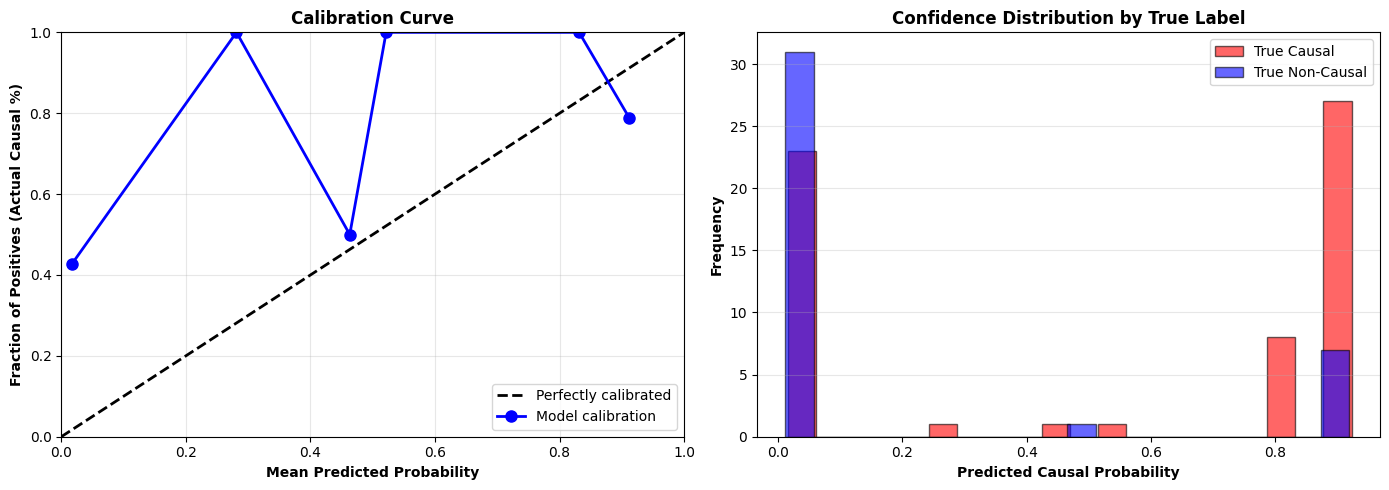


📊 CALIBRATION METRICS:
----------------------------------------------------------------------
Brier Score (lower is better):        0.2962
Log Loss (lower is better):           1.1705
Expected Calibration Error (ECE):    0.3227

📊 RELIABILITY BY CONFIDENCE BINS:
----------------------------------------------------------------------
     Confidence    # Samples     Actual %     Predicted %   Accuracy
----------------------------------------------------------------------
          1.6%           54       42.6%           1.6%     40.9%
         28.1%            0      100.0%          28.1%     71.9%
         46.3%            1       50.0%          46.3%      3.7%
         52.2%            0      100.0%          52.2%     47.8%
         83.1%            2      100.0%          83.1%     16.9%
         91.2%            1       78.8%          91.2%    -12.4%

✅ Calibration analysis complete!


In [15]:
from sklearn.calibration import calibration_curve

print("\n" + "="*70)
print("📈 PREDICTION CALIBRATION & RELIABILITY")
print("="*70)

causal_probs = probabilities[:, 1]
true_labels = test_sample["causal_label"].values[:len(predictions)]

frac_pos, mean_pred = calibration_curve(true_labels, causal_probs, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfectly calibrated')
ax1.plot(mean_pred, frac_pos, 'o-', linewidth=2, markersize=8, label='Model calibration', color='blue')
ax1.set_xlabel('Mean Predicted Probability', fontweight='bold')
ax1.set_ylabel('Fraction of Positives (Actual Causal %)', fontweight='bold')
ax1.set_title('Calibration Curve', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

ax2 = axes[1]
ax2.hist(causal_probs[true_labels == 1], bins=20, alpha=0.6, label='True Causal', color='red', edgecolor='black')
ax2.hist(causal_probs[true_labels == 0], bins=20, alpha=0.6, label='True Non-Causal', color='blue', edgecolor='black')
ax2.set_xlabel('Predicted Causal Probability', fontweight='bold')
ax2.set_ylabel('Frequency', fontweight='bold')
ax2.set_title('Confidence Distribution by True Label', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

from sklearn.metrics import brier_score_loss, log_loss

brier = brier_score_loss(true_labels, causal_probs)
logloss = log_loss(true_labels, probabilities)

print("\n📊 CALIBRATION METRICS:")
print("-" * 70)
print(f"Brier Score (lower is better):        {brier:.4f}")
print(f"Log Loss (lower is better):           {logloss:.4f}")
print(f"Expected Calibration Error (ECE):    {np.mean(np.abs(frac_pos - mean_pred)):.4f}")

print("\n📊 RELIABILITY BY CONFIDENCE BINS:")
print("-" * 70)
print(f"{'Confidence':>15} {'# Samples':>12} {'Actual %':>12} {'Predicted %':>15} {'Accuracy':>10}")
print("-" * 70)

for i in range(len(mean_pred)):
    sample_count = int(((causal_probs >= i/10) & (causal_probs < (i+1)/10)).sum())
    print(f"{mean_pred[i]:>14.1%} {sample_count:>12d} "
          f"{frac_pos[i]:>11.1%} {mean_pred[i]:>14.1%} "
          f"{frac_pos[i] - mean_pred[i]:>9.1%}")

print("\n✅ Calibration analysis complete!")

## Section 12: Interactive Causality Prediction
### Enter Your Own Financial News & Get Causality Probability

In [16]:
def predict_causality(news_text, return_t1=0.0, return_t5=0.0, volatility=0.015):
    """Predict causality for custom financial news with market indicators"""
    
    encoding = tokenizer(
        news_text,
        truncation=True,
        padding="max_length",
        max_length=256,
        return_tensors="pt"
    )
    
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)
    
    numerical_input = np.array([[return_t1, return_t5, volatility]])
    numerical_scaled = scaler.transform(numerical_input)
    numerical_tensor = torch.tensor(numerical_scaled, dtype=torch.float).to(device)
    
    with torch.no_grad():
        logits, attention_weights, text_features, num_features_out = model(
            input_ids, attention_mask, numerical_tensor
        )
        
        probabilities = torch.softmax(logits, dim=1).cpu().numpy()[0]
        prediction = np.argmax(probabilities)
        
        attention_w = attention_weights.cpu().numpy().squeeze()
        tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu().numpy())
    
    token_count = (np.array(tokens) != '[PAD]').sum()
    tokens_clean = tokens[:token_count]
    attention_clean = attention_w[:token_count]
    
    top_token_indices = np.argsort(attention_clean)[-5:][::-1]
    top_tokens_info = [(tokens_clean[i], attention_clean[i]) for i in top_token_indices]
    
    return {
        'news': news_text[:100] + "..." if len(news_text) > 100 else news_text,
        'causal_probability': probabilities[1],
        'non_causal_probability': probabilities[0],
        'prediction': 'CAUSAL' if prediction == 1 else 'NON-CAUSAL',
        'confidence': max(probabilities),
        'top_tokens': top_tokens_info,
        'market_inputs': {
            'return_t1': return_t1,
            'return_t5': return_t5,
            'volatility': volatility
        }
    }

print("="*70)
print("🔮 INTERACTIVE CAUSALITY PREDICTION DEMO")
print("="*70)

test_news_1 = """
Apple announces record Q1 earnings beating analyst expectations by 15%.
CEO Tim Cook reveals major expansion into emerging markets.
Stock futures surge ahead of market open.
"""

result_1 = predict_causality(
    test_news_1,
    return_t1=0.03,
    return_t5=0.08,
    volatility=0.012
)

print(f"\n📰 TEST 1: BULLISH NEWS")
print("-"*70)
print(f"Text: {result_1['news']}")
print(f"\n🎯 Prediction: {result_1['prediction']}")
print(f"   Causal Probability:     {result_1['causal_probability']:.4f} ({result_1['causal_probability']*100:.1f}%)")
print(f"   Non-Causal Probability: {result_1['non_causal_probability']:.4f} ({result_1['non_causal_probability']*100:.1f}%)")
print(f"   Confidence:             {result_1['confidence']:.4f}")
print(f"\n📊 Market Inputs:")
print(f"   Return T+1: {result_1['market_inputs']['return_t1']:+.2%}")
print(f"   Return T+5: {result_1['market_inputs']['return_t5']:+.2%}")
print(f"   Volatility: {result_1['market_inputs']['volatility']:.4f}")
print(f"\n🔤 Top Influential Tokens:")
for i, (token, weight) in enumerate(result_1['top_tokens'], 1):
    print(f"   {i}. '{token}' (attention: {weight:.4f})")

test_news_2 = """
Goldman Sachs downgrades tech sector citing rising interest rates.
Multiple companies report slower-than-expected growth.
Market volatility surges to 6-month highs.
"""

result_2 = predict_causality(
    test_news_2,
    return_t1=-0.025,
    return_t5=-0.05,
    volatility=0.035
)

print(f"\n📰 TEST 2: BEARISH NEWS")
print("-"*70)
print(f"Text: {result_2['news']}")
print(f"\n🎯 Prediction: {result_2['prediction']}")
print(f"   Causal Probability:     {result_2['causal_probability']:.4f} ({result_2['causal_probability']*100:.1f}%)")
print(f"   Non-Causal Probability: {result_2['non_causal_probability']:.4f} ({result_2['non_causal_probability']*100:.1f}%)")
print(f"   Confidence:             {result_2['confidence']:.4f}")
print(f"\n📊 Market Inputs:")
print(f"   Return T+1: {result_2['market_inputs']['return_t1']:+.2%}")
print(f"   Return T+5: {result_2['market_inputs']['return_t5']:+.2%}")
print(f"   Volatility: {result_2['market_inputs']['volatility']:.4f}")
print(f"\n🔤 Top Influential Tokens:")
for i, (token, weight) in enumerate(result_2['top_tokens'], 1):
    print(f"   {i}. '{token}' (attention: {weight:.4f})")

print("\n" + "="*70)
print("✅ TO USE THIS PREDICTOR WITH YOUR OWN NEWS:")
print("="*70)
print("""
result = predict_causality(
    news_text="Your financial news here",
    return_t1=0.02,      # T+1 return percentage
    return_t5=0.05,      # T+5 return percentage  
    volatility=0.015     # 5-day volatility
)

print(result['causal_probability'])  # Causality likelihood
print(result['prediction'])           # CAUSAL or NON-CAUSAL
print(result['top_tokens'])           # Most influential tokens
""")

🔮 INTERACTIVE CAUSALITY PREDICTION DEMO

📰 TEST 1: BULLISH NEWS
----------------------------------------------------------------------
Text: 
Apple announces record Q1 earnings beating analyst expectations by 15%.
CEO Tim Cook reveals major ...

🎯 Prediction: CAUSAL
   Causal Probability:     0.9134 (91.3%)
   Non-Causal Probability: 0.0866 (8.7%)
   Confidence:             0.9134

📊 Market Inputs:
   Return T+1: +3.00%
   Return T+5: +8.00%
   Volatility: 0.0120

🔤 Top Influential Tokens:
   1. 'ahead' (attention: 0.1035)
   2. 'futures' (attention: 0.0582)
   3. '%' (attention: 0.0539)
   4. 'cook' (attention: 0.0491)
   5. 'of' (attention: 0.0477)

📰 TEST 2: BEARISH NEWS
----------------------------------------------------------------------
Text: 
Goldman Sachs downgrades tech sector citing rising interest rates.
Multiple companies report slower...

🎯 Prediction: CAUSAL
   Causal Probability:     0.8897 (89.0%)
   Non-Causal Probability: 0.1103 (11.0%)
   Confidence:             0.8